In [1]:
from dotenv import load_dotenv
from typing import Annotated, List
from langgraph.graph import StateGraph
import os
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage,HumanMessage
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition

In [2]:
#Tools

import arxiv
import wikipedia
from duckduckgo_search import DDGS
from langchain.tools import tool

@tool
def search_arxiv(query_string: str, max_results: int = 2) -> list[dict]:
    """
    Queries the official arXiv API for research papers.
    Returns a list of dictionaries with paper metadata.
    """
    try:
        client = arxiv.Client()
        search = arxiv.Search(
            query=query_string,
            max_results=max_results,
            sort_by=arxiv.SortCriterion.Relevance
        )
        
        papers = []
        # Calling client.results() is the modern, stable 2.x+ pattern
        for result in client.results(search):
            papers.append({
                "title": result.title,
                "summary": result.summary,
                "url": result.entry_id,
                "published": result.published.strftime("%Y-%m-%d"),
                "authors": [author.name for author in result.authors]
            })
        return papers
    except Exception as e:
        return [{"error": f"arXiv search failed: {str(e)}"}]
@tool
def search_wikipedia(query_string: str, sentences: int = 3) -> str:
    """
    Queries Wikipedia for summary definitions.
    Handles disambiguation conflicts safely.
    """
    # Force Wikipedia to look up variations cleanly
    wikipedia.set_lang("en") 
    try:
        # Bypassing background parsing frameworks saves memory
        return wikipedia.summary(query_string, sentences=sentences, auto_suggest=False)
    except Exception as e:
        return f"Wikipedia error: {str(e)}"
@tool
def weather_api():
    '''
    It gives us the weather information of the place
    '''
    return "weather api called"

@tool
def human_approval():
    '''
    The tool should only be called if there is need for human intervention.
    '''
    pass
@tool
def math_operation(a:int,b:int,operator:str):
    '''
    pick this tool when user want to perform some mathematical operations only when there are two numbers.
    operators may be add, sub, mul, divide

    '''
    op=None
    if operator =="add":
        return a+b
    elif operator=="sub":
        return abs(a-b)
    elif operator=="mul":
        return a*b
    elif operator=="div":
        return a/b
    else :
        return None


In [3]:
load_dotenv()
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
tools = [
    search_arxiv, 
    search_wikipedia, 
    weather_api, 
    human_approval, 
    math_operation
]

# Creating Short Term Memory and Long Term Memory of the agent

# Short Term Memory

!) Short term memory: We will use Memorysaver

2)Lifespan: till the programs run

3)Not good for production and long term memory.

In [4]:
'''
BUT LETS SEE, IF WITHOUT MEMORY , HOW IT BEHAVES WITHOUT MEMORY.
'''
#creating state 
class State(BaseModel):
    messages: Annotated[List[AnyMessage],add_messages]=Field(default_factory=list)

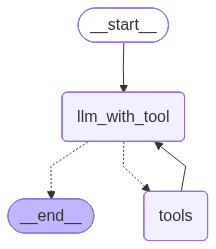

In [5]:
llm=ChatOpenAI(
    model="gpt-4o-mini"
).bind_tools(tools=tools)


#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode)

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
builder.add_edge("llm_with_tool",END)

graph=builder.compile()

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
#LETS TEST OUR GRAPH
res=graph.invoke({"messages":"Hi, I am saurav"})
res['messages']

[HumanMessage(content='Hi, I am saurav', additional_kwargs={}, response_metadata={}, id='e54bf83d-1b73-4c96-a292-e6fdc353b00d'),
 AIMessage(content='Hello Saurav! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 210, 'total_tokens': 223, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_944bbf963c', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019edb38-e4fb-7d63-a72b-9beb8ea9c289-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 210, 'output_tokens': 13, 'total_tokens': 223, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [7]:
# see, Its not remembering my name, since it doesn't have memory.
res=graph.invoke({"messages":["user","what is my name?"]})
res['messages']

[HumanMessage(content='user', additional_kwargs={}, response_metadata={}, id='877d2e1f-643f-4bae-9661-d5e0783788ed'),
 HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='ddb1afa7-21c7-4b3c-b0b1-a69be7d58339'),
 AIMessage(content="I don't have access to your personal information, including your name. However, you can tell me your name if you'd like!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 214, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_944bbf963c', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019edb38-e8ba-7d23-9de8-c64c28bf29a7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 214, 'output_toke

USING MEMORYSAVER:  short term memory

In [8]:
# Using Memorysaver
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

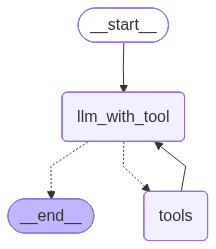

In [9]:
#Lets define our states, edges again .
llm=ChatOpenAI(
    model="gpt-4o-mini"
).bind_tools(tools=tools)


#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode)

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
builder.add_edge("llm_with_tool",END)

graph=builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "chat123"}}

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
events = graph.invoke(
    {"messages": [("user", "My name is saurav, and I live in Pune")]}, 
    config
)
print(events['messages'][-1].content)

Hello Saurav! How can I assist you today?


In [11]:
#  Now the memory is working for agent.
events = graph.invoke(
    {"messages": [HumanMessage(content="hey, whats my name")]}, 
    config
)
print(events['messages'][-1].content)

Your name is Saurav.


In [12]:
'''
Note: There are three ways by which we can write in invoke 
[("user", "text")]
[HumanMessage(content="hey, whats my name")]
["text"]
All of the above are converted anyhow in [HumanMessage(content="hey, whats my name")] , so its the best production practice.

'''

'\nNote: There are three ways by which we can write in invoke \n[("user", "text")]\n[HumanMessage(content="hey, whats my name")]\n["text"]\nAll of the above are converted anyhow in [HumanMessage(content="hey, whats my name")] , so its the best production practice.\n\n'

In [13]:
'''Problem with Short term memory'''
# It will be destroyed upon the finish of the program.
# NOT GOOD FOR PRODUCTION

'Problem with Short term memory'

## Long Term Memory

In [14]:
!pip install --upgrade langgraph langgraph-checkpoint langgraph-checkpoint-sqlite -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn = sqlite3.connect("memory.db", check_same_thread=False)
long_term_memory = SqliteSaver(conn)

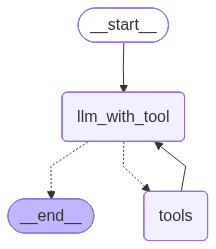

In [16]:
#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode)

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
builder.add_edge("llm_with_tool",END)

graph=builder.compile(checkpointer=long_term_memory)
config = {"configurable": {"thread_id": "chat123"}}

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
config = {"configurable": {"thread_id": "longtermchat#123"}}
res = graph.invoke(
    {"messages": [HumanMessage(content="I am saurav sagar, Hi")]}, 
    config=config # <--- Pass the config dictionary variable here
)
print(res['messages'][-1].content)


Hello Saurav Sagar! How can I assist you today?


In [18]:
res = graph.invoke(
    {"messages": [HumanMessage(content="whats my name")]}, 
    config=config # <--- Pass the config dictionary variable here
)
print(res['messages'][-1].content)

Your name is Saurav Sagar. How can I help you further?


In [19]:
res = graph.invoke(
    {"messages": [HumanMessage(content="have I told you about my name")]}, 
    config=config # <--- Pass the config dictionary variable here
)
print(res['messages'][-1].content)

Yes, you mentioned your name is Saurav Sagar. If there's anything specific you'd like to discuss or ask about, feel free to let me know!
